# Fine Particles (PM 2.5) Analysis: Population-Based Comparison

Comparing STL (Seasonal and Trend decomposition using LOESS) components of Fine Particles across NYC Community Districts grouped by population level.

**Research Question:** Do high-population and low-population CDs show different patterns in PM 2.5 time series decomposition?

**Methodology:**
1. Run STL decomposition on all CD time series for PM 2.5 only
2. Split CDs into two groups based on population (median split)
3. Extract trend slope, seasonal amplitude, and residual RMSE for each CD
4. Compare metrics between groups using Mann-Whitney U test (nonparametric)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../DATA/Air_Quality_Cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Data loaded: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nGeo Type Names: {df['Geo Type Name'].unique()}")

Data loaded: (18862, 13)
Date range: 2005-01-01 00:00:00 to 2023-06-01 00:00:00

Column names: ['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info', 'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period', 'Start_Date', 'Data Value', 'Message', 'Date']

Geo Type Names: ['Borough' 'UHF42' 'CD' 'Citywide' 'UHF34']


In [3]:
# Identify all CDs and extract CD numbers
import re

cd_data = df[df['Geo Type Name'] == 'CD'].copy()

# Extract CD number from location name
cd_data['CD_Number'] = cd_data['Geo Place Name'].str.extract(r'\(CD(\d+)\)')[0].astype(int)

# Get counts
cd_counts = cd_data.groupby('CD_Number').size()
print(f"Total unique CDs: {len(cd_counts)}")
print(f"\nCD record counts:\n{cd_counts.sort_index()}")

unique_cds = sorted(cd_counts.index.tolist())
print(f"\nCD numbers: {unique_cds}")

Total unique CDs: 18

CD record counts:
CD_Number
1     580
2     580
3     580
4     464
5     464
6     464
7     464
8     464
9     464
10    464
11    464
12    464
13    232
14    232
15    116
16    116
17    116
18    116
dtype: int64

CD numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


In [4]:
# Create population-based grouping (2020 Census data)
# Population for each NYC Community District
cd_population = {
    1: 254000,   # Battery Park City/Lower Manhattan
    2: 293000,   # Lower East Side/East Village
    3: 318000,   # Greenwich Village/Financial District
    4: 270000,   # Chelsea/Clinton
    5: 321000,   # Midtown
    6: 399000,   # Upper West Side
    7: 418000,   # Upper East Side
    8: 318000,   # Central Harlem
    9: 290000,   # East Harlem
    10: 275000,  # South Bronx
    11: 399000,  # Lower Bronx
    12: 310000,  # East Bronx
    13: 268000,  # Southeast Bronx
    14: 403000,  # North Brooklyn
    15: 302000,  # Northwest Brooklyn
    16: 287000,  # Northeast Brooklyn
    17: 413000,  # Southeast Brooklyn
    18: 287000   # Southwest Brooklyn
}

# Calculate median population
populations = [cd_population[cd] for cd in unique_cds if cd in cd_population]
median_pop = np.median(populations)

print(f"Population statistics:")
print(f"  Median: {median_pop:,.0f}")
print(f"  Min: {min(populations):,.0f}")
print(f"  Max: {max(populations):,.0f}")

# Split into high and low population groups
cd_group = {}
high_pop_cds = []
low_pop_cds = []

for cd in unique_cds:
    if cd in cd_population:
        if cd_population[cd] >= median_pop:
            cd_group[cd] = 'High Population'
            high_pop_cds.append(cd)
        else:
            cd_group[cd] = 'Low Population'
            low_pop_cds.append(cd)

high_pop_cds = sorted(high_pop_cds)
low_pop_cds = sorted(low_pop_cds)

print(f"\nHigh Population CDs (n={len(high_pop_cds)}): {high_pop_cds}")
print(f"Low Population CDs (n={len(low_pop_cds)}): {low_pop_cds}")

Population statistics:
  Median: 306,000
  Min: 254,000
  Max: 418,000

High Population CDs (n=9): [3, 5, 6, 7, 8, 11, 12, 14, 17]
Low Population CDs (n=9): [1, 2, 4, 9, 10, 13, 15, 16, 18]


In [5]:
# Run STL decomposition on all CDs for PM 2.5 only
stl_results = {}

pollutants_to_analyze = ['Fine particles (PM 2.5)']

for pollutant in pollutants_to_analyze:
    stl_results[pollutant] = {}
    
    for cd_num in unique_cds:
        try:
            # Get data for this CD and pollutant
            mask = (cd_data['CD_Number'] == cd_num) & (cd_data['Name'] == pollutant)
            cd_poll_data = cd_data[mask].sort_values('Date')[['Date', 'Data Value']]
            
            if len(cd_poll_data) < 24:  # Need at least 24 obs for STL
                print(f"  CD{cd_num}: Insufficient data ({len(cd_poll_data)} obs)")
                continue
            
            # Create time series
            ts = cd_poll_data.set_index('Date')['Data Value'].astype(float)
            
            # Remove NaN values
            ts = ts.dropna()
            
            if len(ts) < 24:
                print(f"  CD{cd_num}: Insufficient non-null data ({len(ts)} obs)")
                continue
            
            # Run STL with seasonal=13 (2+ year cycle for monthly data)
            stl = STL(ts, seasonal=13, period=12, trend=15)
            result = stl.fit()
            
            stl_results[pollutant][cd_num] = {
                'ts': ts,
                'result': result,
                'n_obs': len(ts)
            }
            
        except Exception as e:
            print(f"  CD{cd_num}: Error - {str(e)}")
            continue

# Summary
print("\nSTL Decomposition Summary:")
for pollutant in pollutants_to_analyze:
    successful = len(stl_results[pollutant])
    print(f"  {pollutant}: {successful}/{len(unique_cds)} CDs successful")


STL Decomposition Summary:
  Fine particles (PM 2.5): 18/18 CDs successful


In [6]:
# Extract STL metrics for statistical comparison
from scipy import stats as sp_stats

def extract_stl_metrics(stl_result, ts):
    """Extract key metrics from STL decomposition"""
    trend = stl_result.trend
    seasonal = stl_result.seasonal
    residual = stl_result.resid
    
    # Trend slope: linear regression slope
    x = np.arange(len(trend))
    slope, _, _, _, _ = sp_stats.linregress(x, trend)
    
    # Seasonal amplitude: max - min
    seasonal_amp = seasonal.max() - seasonal.min()
    
    # Residual RMSE
    residual_rmse = np.sqrt(np.mean(residual**2))
    
    return {
        'trend_slope': slope,
        'seasonal_amplitude': seasonal_amp,
        'residual_rmse': residual_rmse
    }

# Extract metrics for all decompositions
metrics_summary = {}

for pollutant in pollutants_to_analyze:
    metrics_summary[pollutant] = {
        'High Population': [],
        'Low Population': []
    }
    
    for cd_num in stl_results[pollutant]:
        stl_result = stl_results[pollutant][cd_num]['result']
        ts = stl_results[pollutant][cd_num]['ts']
        
        metrics = extract_stl_metrics(stl_result, ts)
        metrics['cd'] = cd_num
        
        group = cd_group[cd_num]
        metrics_summary[pollutant][group].append(metrics)

# Display summary statistics by group
print("\nMetrics Summary by Population Group:\n")
for pollutant in pollutants_to_analyze:
    print(f"{pollutant}:")
    for group in ['High Population', 'Low Population']:
        data = metrics_summary[pollutant][group]
        if data:
            trend_slopes = [m['trend_slope'] for m in data]
            seasonal_amps = [m['seasonal_amplitude'] for m in data]
            residual_rmses = [m['residual_rmse'] for m in data]
            
            print(f"  {group} (n={len(data)}):")
            print(f"    Trend Slope:        mean={np.mean(trend_slopes):.4f}, std={np.std(trend_slopes):.4f}")
            print(f"    Seasonal Amplitude: mean={np.mean(seasonal_amps):.4f}, std={np.std(seasonal_amps):.4f}")
            print(f"    Residual RMSE:      mean={np.mean(residual_rmses):.4f}, std={np.std(residual_rmses):.4f}")


Metrics Summary by Population Group:

Fine particles (PM 2.5):
  High Population (n=9):
    Trend Slope:        mean=-0.0433, std=0.0281
    Seasonal Amplitude: mean=3.1578, std=0.7025
    Residual RMSE:      mean=0.8910, std=0.3009
  Low Population (n=9):
    Trend Slope:        mean=-0.0571, std=0.0372
    Seasonal Amplitude: mean=2.8952, std=0.5921
    Residual RMSE:      mean=0.7011, std=0.1894



Spearman correlation for Fine particles (PM 2.5) (population vs trend_slope):
  n=18, rho=-0.1592, p-value=0.5281


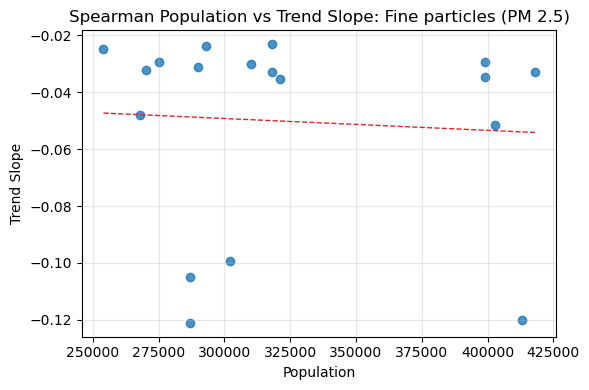


Spearman summary:
              pollutant       rho  p_value  n
Fine particles (PM 2.5) -0.159173 0.528122 18


In [7]:
# Spearman correlation: population vs trend_slope across CDs
from scipy.stats import spearmanr

spearman_results = []

for pollutant in pollutants_to_analyze:
    trend_rows = []
    for cd_num in stl_results[pollutant]:
        if cd_num not in cd_population:
            continue
        metrics = extract_stl_metrics(stl_results[pollutant][cd_num]['result'], stl_results[pollutant][cd_num]['ts'])
        trend_rows.append({
            'cd': cd_num,
            'population': cd_population[cd_num],
            'trend_slope': metrics['trend_slope']
        })

    trend_df = pd.DataFrame(trend_rows)
    if len(trend_df) < 2:
        print(f"Not enough CDs to compute Spearman for {pollutant}")
        continue

    rho, pval = spearmanr(trend_df['population'], trend_df['trend_slope'])
    spearman_results.append({
        'pollutant': pollutant,
        'rho': rho,
        'p_value': pval,
        'n': len(trend_df)
    })

    print(f"\nSpearman correlation for {pollutant} (population vs trend_slope):")
    print(f"  n={len(trend_df)}, rho={rho:.4f}, p-value={pval:.4f}")

    # Plot scatter with trend line
    plt.figure(figsize=(6, 4))
    plt.scatter(trend_df['population'], trend_df['trend_slope'], c='tab:blue', alpha=0.8)
    z = np.polyfit(trend_df['population'], trend_df['trend_slope'], 1)
    p = np.poly1d(z)
    xp = np.linspace(trend_df['population'].min(), trend_df['population'].max(), 100)
    plt.plot(xp, p(xp), color='tab:red', linestyle='--', linewidth=1)
    plt.title(f"Spearman Population vs Trend Slope: {pollutant}")
    plt.xlabel('Population')
    plt.ylabel('Trend Slope')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

spearman_df = pd.DataFrame(spearman_results)
print("\nSpearman summary:")
print(spearman_df.to_string(index=False))

In [6]:
# Run Mann-Whitney U tests comparing groups
statistical_results = {}

print("\n" + "="*80)
print("MANN-WHITNEY U TEST RESULTS")
print("="*80)

for pollutant in pollutants_to_analyze:
    statistical_results[pollutant] = {}
    
    print(f"\n{pollutant}:")
    print("-" * 80)
    
    for metric in ['trend_slope', 'seasonal_amplitude', 'residual_rmse']:
        high_pop_values = np.array([m[metric] for m in metrics_summary[pollutant]['High Population']])
        low_pop_values = np.array([m[metric] for m in metrics_summary[pollutant]['Low Population']])
        
        # Mann-Whitney U test
        statistic, p_value = mannwhitneyu(high_pop_values, low_pop_values)
        
        # Effect size: rank biserial correlation
        n1, n2 = len(high_pop_values), len(low_pop_values)
        r = 1 - (2*statistic) / (n1 * n2)
        
        statistical_results[pollutant][metric] = {
            'statistic': statistic,
            'p_value': p_value,
            'effect_size': r,
            'high_mean': np.mean(high_pop_values),
            'low_mean': np.mean(low_pop_values),
            'high_cds': [m['cd'] for m in metrics_summary[pollutant]['High Population']],
            'low_cds': [m['cd'] for m in metrics_summary[pollutant]['Low Population']]
        }
        
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "†" if p_value < 0.1 else "ns"
        
        print(f"\n  {metric}:")
        print(f"    High Pop (n={len(high_pop_values)}): μ={np.mean(high_pop_values):.4f} (σ={np.std(high_pop_values):.4f})")
        print(f"    Low Pop  (n={len(low_pop_values)}): μ={np.mean(low_pop_values):.4f} (σ={np.std(low_pop_values):.4f})")
        print(f"    U={statistic:.0f}, p={p_value:.4f} {sig}, r={r:.3f}")

print("\n" + "="*80)


MANN-WHITNEY U TEST RESULTS

Fine particles (PM 2.5):
--------------------------------------------------------------------------------

  trend_slope:
    High Pop (n=9): μ=-0.0433 (σ=0.0281)
    Low Pop  (n=9): μ=-0.0571 (σ=0.0372)
    U=42, p=0.9296 ns, r=-0.037

  seasonal_amplitude:
    High Pop (n=9): μ=3.1578 (σ=0.7025)
    Low Pop  (n=9): μ=2.8952 (σ=0.5921)
    U=45, p=0.7239 ns, r=-0.111

  residual_rmse:
    High Pop (n=9): μ=0.8910 (σ=0.3009)
    Low Pop  (n=9): μ=0.7011 (σ=0.1894)
    U=55, p=0.2164 ns, r=-0.358



✓ Visualization saved: STL_Fine_Particles_Comparison.png


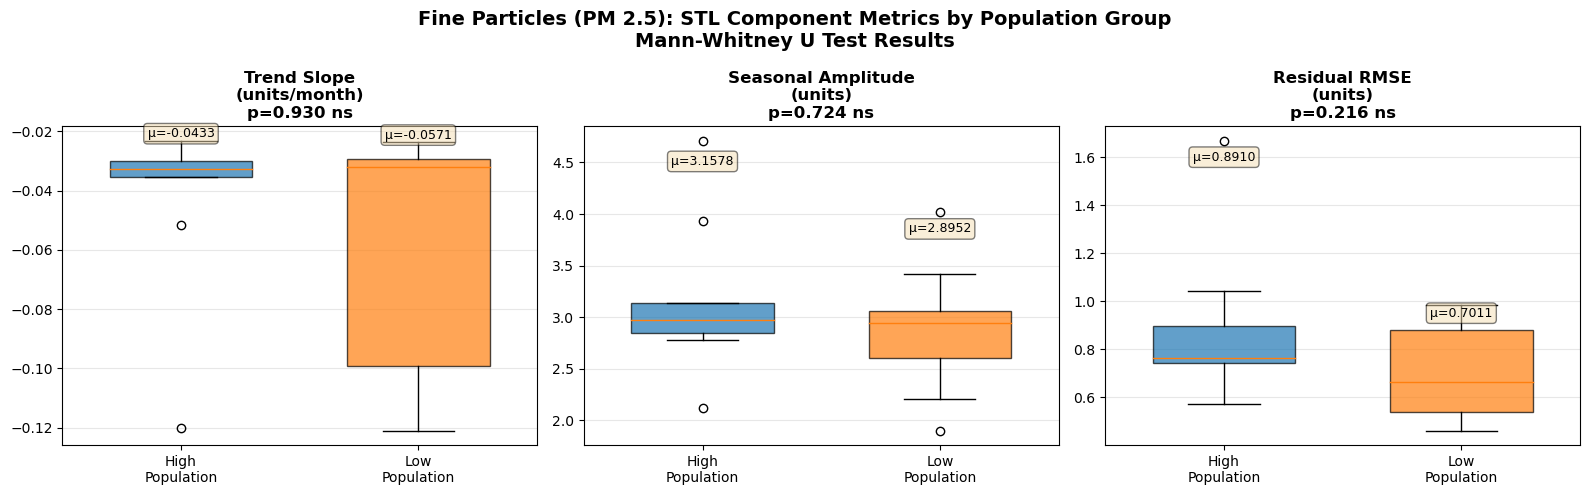

In [7]:
# Create visualizations for PM 2.5 only
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fine Particles (PM 2.5): STL Component Metrics by Population Group\nMann-Whitney U Test Results', 
             fontsize=14, fontweight='bold')

pollutant = 'Fine particles (PM 2.5)'
metric_names = ['trend_slope', 'seasonal_amplitude', 'residual_rmse']
metric_labels = ['Trend Slope\n(units/month)', 'Seasonal Amplitude\n(units)', 'Residual RMSE\n(units)']

for col, (metric, label) in enumerate(zip(metric_names, metric_labels)):
    ax = axes[col]
    
    # Get data for both groups
    high_values = np.array([m[metric] for m in metrics_summary[pollutant]['High Population']])
    low_values = np.array([m[metric] for m in metrics_summary[pollutant]['Low Population']])
    
    # Create box plot
    bp = ax.boxplot([high_values, low_values], labels=['High\nPopulation', 'Low\nPopulation'],
                    patch_artist=True, widths=0.6)
    
    # Style
    colors = ['#1f77b4', '#ff7f0e']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Get test results
    stats = statistical_results[pollutant][metric]
    p_val = stats['p_value']
    
    # Add significance marker
    sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "†" if p_val < 0.1 else "ns"
    if p_val < 0.1:
        title_color = '#FF6B6B'
    else:
        title_color = 'black'
    
    ax.set_title(f'{label}\np={p_val:.3f} {sig_marker}', color=title_color, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add mean values as text
    ax.text(1, high_values.max()*0.95, f'μ={np.mean(high_values):.4f}', 
           fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.text(2, low_values.max()*0.95, f'μ={np.mean(low_values):.4f}',
           fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../OUTPUT/STL_Fine_Particles_Comparison.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: STL_Fine_Particles_Comparison.png")
plt.show()

In [8]:
# Create and export summary results table
results_data = []

for pollutant in pollutants_to_analyze:
    for metric in ['trend_slope', 'seasonal_amplitude', 'residual_rmse']:
        stats = statistical_results[pollutant][metric]
        metric_label = {'trend_slope': 'Trend Slope', 
                       'seasonal_amplitude': 'Seasonal Amplitude',
                       'residual_rmse': 'Residual RMSE'}[metric]
        
        p = stats['p_value']
        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        elif p < 0.1:
            sig = "† (marginal)"
        else:
            sig = "ns"
        
        results_data.append({
            'Pollutant': pollutant,
            'Metric': metric_label,
            'High Pop Mean': f"{stats['high_mean']:.4f}",
            'Low Pop Mean': f"{stats['low_mean']:.4f}",
            'U-statistic': stats['statistic'],
            'p-value': f"{p:.4f}",
            'Effect Size (r)': f"{stats['effect_size']:.3f}",
            'Significance': sig
        })

results_df = pd.DataFrame(results_data)

print("\n" + "="*120)
print("STATISTICAL COMPARISON SUMMARY TABLE")
print("="*120)
print(results_df.to_string(index=False))
print("="*120)

# Export to CSV
results_df.to_csv('../OUTPUT/STL_Statistical_Results.csv', index=False)
print("\n✓ Results exported to: STL_Statistical_Results.csv")


STATISTICAL COMPARISON SUMMARY TABLE
              Pollutant             Metric High Pop Mean Low Pop Mean  U-statistic p-value Effect Size (r) Significance
Fine particles (PM 2.5)        Trend Slope       -0.0433      -0.0571         42.0  0.9296          -0.037           ns
Fine particles (PM 2.5) Seasonal Amplitude        3.1578       2.8952         45.0  0.7239          -0.111           ns
Fine particles (PM 2.5)      Residual RMSE        0.8910       0.7011         55.0  0.2164          -0.358           ns

✓ Results exported to: STL_Statistical_Results.csv
